In [1]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             f1_score, classification_report,
                             precision_recall_curve)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/processed/train_processed.csv')

X = df.drop(columns=['isFraud'])
y = df['isFraud']

print(f"Features: {X.shape}")

Features: (590540, 434)


In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserve fraud rate in both splits
)

print(f"Train: {X_train.shape} | Fraud rate: {y_train.mean()*100:.2f}%")
print(f"Val:   {X_val.shape}   | Fraud rate: {y_val.mean()*100:.2f}%")

Train: (472432, 434) | Fraud rate: 3.50%
Val:   (118108, 434)   | Fraud rate: 3.50%


In [4]:
smote = SMOTE(random_state=42, sampling_strategy=0.1)  # don't fully balance, just reduce imbalance
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"After SMOTE — Train shape: {X_train_sm.shape}")
print(f"Fraud rate after SMOTE: {y_train_sm.mean()*100:.2f}%")

After SMOTE — Train shape: (501492, 434)
Fraud rate after SMOTE: 9.09%


In [5]:
def evaluate_model(model, X_val, y_val, model_name):
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)

    roc_auc  = roc_auc_score(y_val, y_pred_proba)
    pr_auc   = average_precision_score(y_val, y_pred_proba)
    f1       = f1_score(y_val, y_pred)

    print(f"\n{'='*40}")
    print(f"  {model_name}")
    print(f"{'='*40}")
    print(f"  ROC-AUC  : {roc_auc:.4f}")
    print(f"  PR-AUC   : {pr_auc:.4f}  ← main metric (imbalanced data)")
    print(f"  F1 Score : {f1:.4f}")
    print(f"\n{classification_report(y_val, y_pred, target_names=['Legit','Fraud'])}")

    return roc_auc, pr_auc, f1, y_pred_proba

In [7]:
# Use SQLite backend instead of filesystem
mlflow.set_tracking_uri('sqlite:///../mlflow/mlflow.db')
mlflow.set_experiment('fraud-detection')

2026/07/08 02:08:30 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/08 02:08:30 INFO mlflow.store.db.utils: Updating database tables
2026/07/08 02:08:33 INFO mlflow.tracking.fluent: Experiment with name 'fraud-detection' does not exist. Creating a new experiment.


<Experiment: artifact_location=('file:c:/Users/ansul/OneDrive/Desktop/data science '
 'project/fraud-detection-mlops/notebooks/mlruns/1'), creation_time=1783456713705, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1783456713705, lifecycle_stage='active', name='fraud-detection', tags={}, trace_location=None, workspace='default'>

In [8]:
xgb_params = {
    'n_estimators'    : 500,
    'max_depth'       : 6,
    'learning_rate'   : 0.05,
    'subsample'       : 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': 10,   # handles class imbalance
    'random_state'    : 42,
    'n_jobs'          : -1,
    'eval_metric'     : 'aucpr'
}


with mlflow.start_run(run_name="XGBoost"):
    xgb_model = xgb.XGBClassifier(**xgb_params)
    xgb_model.fit(
        X_train_sm, y_train_sm,
        eval_set=[(X_val, y_val)],
        verbose=100
    )

    roc, pr, f1, xgb_proba = evaluate_model(xgb_model, X_val, y_val, "XGBoost")

    # Log to MLflow
    mlflow.log_params(xgb_params)
    mlflow.log_metric("roc_auc", roc)
    mlflow.log_metric("pr_auc", pr)
    mlflow.log_metric("f1_score", f1)
    mlflow.xgboost.log_model(xgb_model, "xgboost_model")

[0]	validation_0-aucpr:0.28070
[100]	validation_0-aucpr:0.55157
[200]	validation_0-aucpr:0.61358
[300]	validation_0-aucpr:0.65252
[400]	validation_0-aucpr:0.68355
[499]	validation_0-aucpr:0.70771

  XGBoost
  ROC-AUC  : 0.9484
  PR-AUC   : 0.7077  ← main metric (imbalanced data)
  F1 Score : 0.6012

              precision    recall  f1-score   support

       Legit       0.99      0.98      0.98    113975
       Fraud       0.51      0.73      0.60      4133

    accuracy                           0.97    118108
   macro avg       0.75      0.85      0.79    118108
weighted avg       0.97      0.97      0.97    118108



2026/07/08 02:22:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [9]:
lgb_params = {
    'n_estimators'   : 500,
    'max_depth'      : 6,
    'learning_rate'  : 0.05,
    'subsample'      : 0.8,
    'colsample_bytree': 0.8,
    'class_weight'   : 'balanced',
    'random_state'   : 42,
    'n_jobs'         : -1,
    'verbose'        : -1
}

print("Training LightGBM... (3-5 mins on CPU)")

with mlflow.start_run(run_name="LightGBM"):
    lgb_model = lgb.LGBMClassifier(**lgb_params)
    lgb_model.fit(
        X_train_sm, y_train_sm,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
    )

    roc, pr, f1, lgb_proba = evaluate_model(lgb_model, X_val, y_val, "LightGBM")

    # Log to MLflow
    mlflow.log_params(lgb_params)
    mlflow.log_metric("roc_auc", roc)
    mlflow.log_metric("pr_auc", pr)
    mlflow.log_metric("f1_score", f1)
    mlflow.lightgbm.log_model(lgb_model, "lgbm_model")


Training LightGBM... (3-5 mins on CPU)
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.23158
[200]	valid_0's binary_logloss: 0.193707
[300]	valid_0's binary_logloss: 0.176808
[400]	valid_0's binary_logloss: 0.164108
[500]	valid_0's binary_logloss: 0.154906
Did not meet early stopping. Best iteration is:
[500]	valid_0's binary_logloss: 0.154906


2026/07/08 02:38:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  LightGBM
  ROC-AUC  : 0.9410
  PR-AUC   : 0.6815  ← main metric (imbalanced data)
  F1 Score : 0.5703

              precision    recall  f1-score   support

       Legit       0.99      0.97      0.98    113975
       Fraud       0.48      0.71      0.57      4133

    accuracy                           0.96    118108
   macro avg       0.73      0.84      0.78    118108
weighted avg       0.97      0.96      0.97    118108


LightGBM run logged to MLflow ✅


In [11]:
with mlflow.start_run(run_name="Ensemble_XGB_LGB"):

    # Simple average of both model probabilities
    ensemble_proba = (xgb_proba + lgb_proba) / 2
    ensemble_pred  = (ensemble_proba >= 0.5).astype(int)

    roc  = roc_auc_score(y_val, ensemble_proba)
    pr   = average_precision_score(y_val, ensemble_proba)
    f1   = f1_score(y_val, ensemble_pred)

    print(f"\n{'='*40}")
    print(f"  Ensemble (XGBoost + LightGBM)")
    print(f"{'='*40}")
    print(f"  ROC-AUC : {roc:.4f}")
    print(f"  PR-AUC  : {pr:.4f}  ← main metric")
    print(f"  F1      : {f1:.4f}")

    mlflow.log_metric("roc_auc", roc)
    mlflow.log_metric("pr_auc", pr)
    mlflow.log_metric("f1_score", f1)



  Ensemble (XGBoost + LightGBM)
  ROC-AUC : 0.9457
  PR-AUC  : 0.6980  ← main metric
  F1      : 0.5917


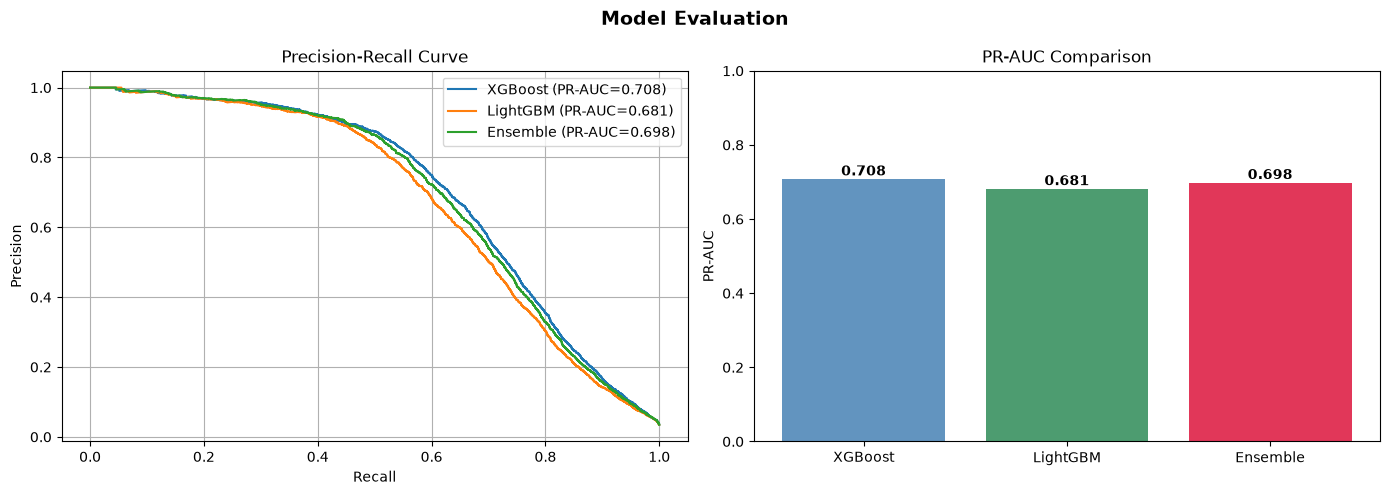

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR Curve
for name, proba in [("XGBoost", xgb_proba),
                     ("LightGBM", lgb_proba),
                     ("Ensemble", ensemble_proba)]:
    precision, recall, _ = precision_recall_curve(y_val, proba)
    pr_auc = average_precision_score(y_val, proba)
    axes[0].plot(recall, precision, label=f"{name} (PR-AUC={pr_auc:.3f})")

axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()
axes[0].grid(True)

# Model comparison bar chart
models     = ['XGBoost', 'LightGBM', 'Ensemble']
pr_scores  = [
    average_precision_score(y_val, xgb_proba),
    average_precision_score(y_val, lgb_proba),
    average_precision_score(y_val, ensemble_proba)
]
colors = ['steelblue', 'seagreen', 'crimson']
axes[1].bar(models, pr_scores, color=colors, alpha=0.85)
axes[1].set_title('PR-AUC Comparison')
axes[1].set_ylabel('PR-AUC')
axes[1].set_ylim(0, 1)
for i, v in enumerate(pr_scores):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')

plt.suptitle('Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../mlflow/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
import joblib, os
os.makedirs('../models', exist_ok=True)

# Save whichever scored higher
joblib.dump(xgb_model, '../models/xgb_model.pkl')
joblib.dump(lgb_model, '../models/lgb_model.pkl')

# Save ensemble probabilities for later use
np.save('../models/xgb_val_proba.npy', xgb_proba)
np.save('../models/lgb_val_proba.npy', lgb_proba)
